In [1]:
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from pathlib import Path
DB_PATH = Path("../data/raw/ventas.db")
conn = sqlite3.connect(DB_PATH)

def sql(query, params=None):
    return pd.read_sql_query(query, conn, params=params)

# Extraccion y preparacion de datos

In [2]:
df_modelo = sql("""
SELECT v.cantidad, v.descuento_pct, p.categoria, p.precio_unitario FROM ventas v
JOIN productos p
    ON v.producto_id = p.producto_id
""")
df_modelo.shape

(379, 4)

In [3]:
df_modelo["ingreso"] = df_modelo["cantidad"] * df_modelo["precio_unitario"] * (1 - df_modelo["descuento_pct"] / 100.0)
df_modelo.head()

,cantidad,descuento_pct,categoria,precio_unitario,ingreso
0,6,0.0,Electrónica,143100.0,858600.0
1,4,0.0,Deportes,45000.0,180000.0
2,7,5.0,Belleza,415800.0,2765070.0
3,5,20.0,Electrónica,272100.0,1088400.0
4,2,10.0,Belleza,371200.0,668160.0


In [4]:
df_modelo.corr(numeric_only=True)["ingreso"]

cantidad           0.600805
descuento_pct      0.007194
precio_unitario    0.753761
ingreso            1.000000
Name: ingreso, dtype: float64

# Exploracion antes de modelo

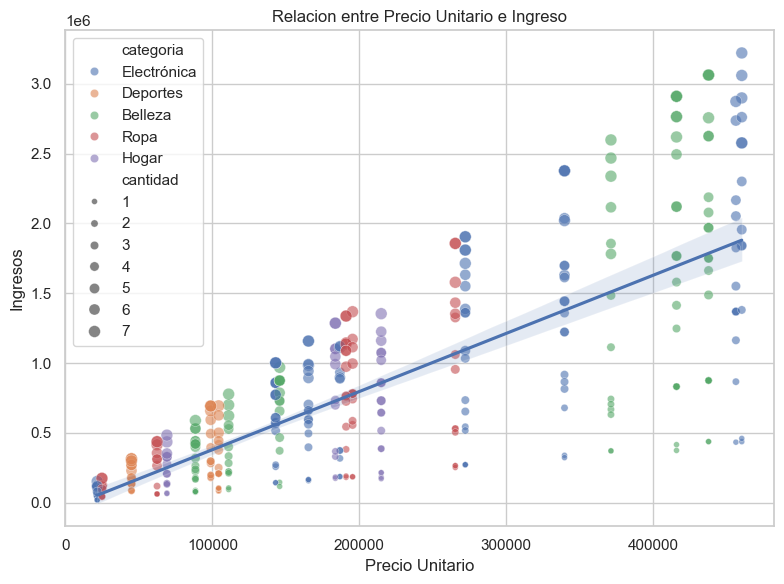

In [5]:
sns.set_theme(style="whitegrid", palette="deep")
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_modelo,
    x="precio_unitario",
    y="ingreso",
    hue="categoria",
    size="cantidad",
    alpha=0.6
)

sns.regplot(
    data=df_modelo,
    x="precio_unitario",
    y="ingreso",
    scatter=False
)
plt.title("Relacion entre Precio Unitario e Ingreso")
plt.xlabel("Precio Unitario")
plt.ylabel("Ingresos")
plt.tight_layout()
plt.show()

# Preparacion de Features

In [6]:
df_encoded = pd.get_dummies(
    df_modelo,
    columns=["categoria"],
    drop_first=True
).astype(int)
df_encoded.head(3)

,cantidad,descuento_pct,precio_unitario,ingreso,categoria_Deportes,categoria_Electrónica,categoria_Hogar,categoria_Ropa
0,6,0,143100,858600,0,1,0,0
1,4,0,45000,180000,1,0,0,0
2,7,5,415800,2765070,0,0,0,0


# Train/Test Modelo

In [7]:
df_encoded.columns

Index(['cantidad', 'descuento_pct', 'precio_unitario', 'ingreso',
       'categoria_Deportes', 'categoria_Electrónica', 'categoria_Hogar',
       'categoria_Ropa'],
      dtype='str')

In [8]:
X = df_encoded[['cantidad', 'descuento_pct', 'precio_unitario', 'categoria_Deportes', 
        'categoria_Electrónica', 'categoria_Hogar', 'categoria_Ropa']]

y = df_encoded["ingreso"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print(f"Filas en X train: {X_train.shape[0]}")
print(f"Filas en Y train: {y_train.shape[0]}")
print(f"Filas en X test: {X_test.shape[0]}")
print(f"Filas en Y test: {y_test.shape[0]}")

Filas en X train: 303
Filas en Y train: 303
Filas en X test: 76
Filas en Y test: 76


# Entrenamiento del modelo

In [10]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
df_predicciones = pd.DataFrame({
    "Variables": X_train.columns,
    "Coeficiente": modelo.coef_
})

In [12]:
df_predicciones.sort_values("Coeficiente", ascending=False)

,Variables,Coeficiente
0,cantidad,202359.555177
3,categoria_Deportes,17057.179232
4,categoria_Electrónica,16091.479363
5,categoria_Hogar,13955.851920
2,precio_unitario,3.936059
1,descuento_pct,-5060.856888
6,categoria_Ropa,-47827.849673


In [13]:
y_pred = modelo.predict(X_test)

# Evaluacion del Modelo

#### Para el R² se espera un resultado estimado del 0.70 para el modelo de prediccion debido a que dos de las tres variables evaluadas junto a ingresos en correlacion, dieron un resultado por encima de 0.5 siendo estos resultados aceptables para el modelo

In [14]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(r2)
print(mae)

0.8385713363168085
192621.69704647546


In [15]:
ticketPromedio = df_modelo["ingreso"].mean()
ticketPromedio

np.float64(842265.6068601583)

In [16]:
porcentaje_mae = (mae/ticketPromedio)*100
print(f"El MAE representa el {porcentaje_mae:.2f}% del ticket promedio")

El MAE representa el 22.87% del ticket promedio


# Visualizacion

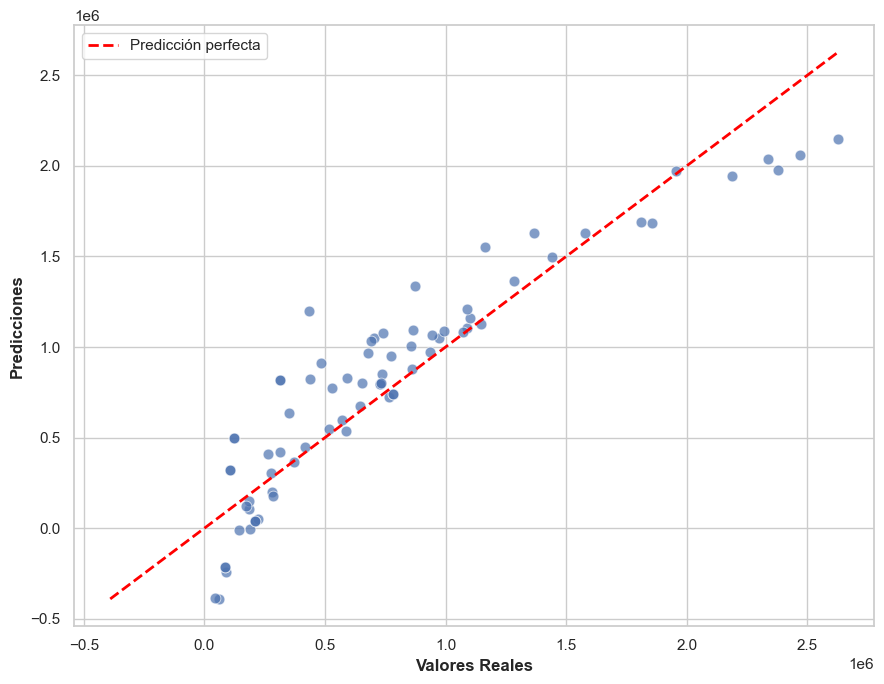

In [17]:
sns.set_theme(style="whitegrid", palette="deep")
plt.figure(figsize=(9, 7))
sns.scatterplot(
    x = y_test,
    y = y_pred,
    alpha=0.7,
    s=60
)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Predicción perfecta"
)
plt.xlabel("Valores Reales", fontweight="bold")
plt.ylabel("Predicciones", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

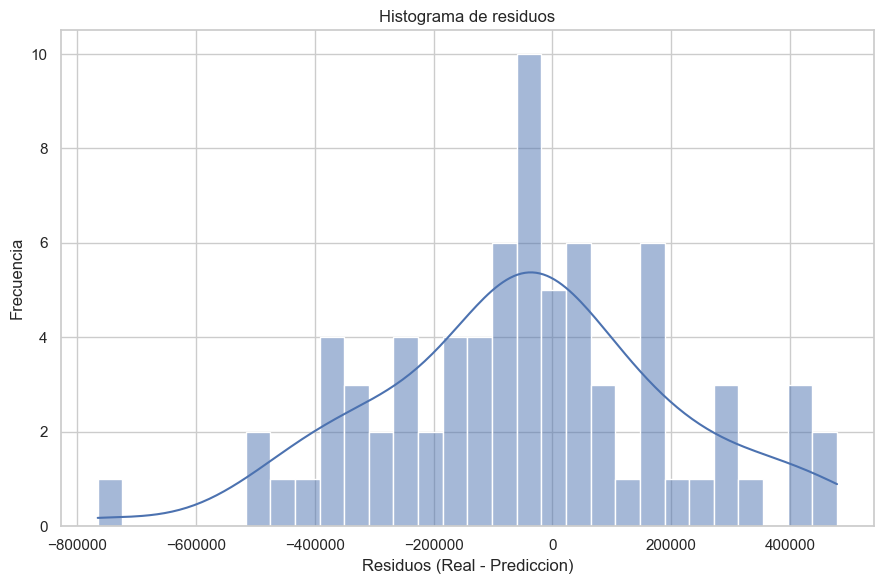

In [18]:
sns.set_theme(style="whitegrid", palette="deep")
plt.figure(figsize=(9, 6))
residuos = y_test - y_pred
sns.histplot(residuos, bins=30, kde=True)
plt.xlabel("Residuos (Real - Prediccion)")
plt.ylabel("Frecuencia")
plt.title("Histograma de residuos")
plt.tight_layout()
plt.show()